In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

## Task 1: Build and Summarize Synthetic Datasets
Start by creating three synthetic datasets that represent different distribution shapes. Each dataset should have 500 observations.

**Dataset A** — Symmetric: draw from a normal distribution with mean = 50 and standard deviation = 10.

**Dataset B** — Right-skewed: draw from an exponential distribution, then shift and scale so the values fall roughly in the 0–100 range.

**Dataset C** — Bimodal: combine two normal distributions (e.g., means at 30 and 70) with equal sample sizes.
For each dataset, compute and display in a summary table:

Mean, median, mode (rounded to 2 decimals)

Standard deviation, variance, IQR

Skewness and kurtosis (use scipy.stats.skew and scipy.stats.kurtosis)

Guiding question: Which summary statistics look similar across the three datasets, and which reveal the differences?

In [7]:
# Dataset A: Symmetric (Normal Distribution)
dataset_A = np.random.normal(loc=50, scale=10, size=500)

# Dataset B: Right-skewed (Exponential Distribution)
dataset_B = np.random.exponential(scale=1, size=500)
dataset_B = dataset_B / dataset_B.max() * 100

# Dataset C: Bimodal Distribution
data1 = np.random.normal(30, 5, 250)
data2 = np.random.normal(70, 5, 250)
dataset_C = np.concatenate([data1, data2])

In [8]:
df = pd.DataFrame({
    "Dataset_A": dataset_A,
    "Dataset_B": dataset_B,
    "Dataset_C": dataset_C
})

In [10]:
summary= pd.DataFrame( {
    "Mean" : df.mean(),
    "Median" : df.median(),
    "Mode" : df.mode().iloc[0],
    "Std dev" : df.std(),
    "Var" :df.var(),
    "IQR" : df.quantile(0.75)-df.quantile(0.25),
    "Skewness" : df.apply(stats.skew),
    "Kurtosis" : df.apply(stats.kurtosis)
}).round(2)
summary

,Mean,Median,Mode,Std dev,Var,IQR,Skewness,Kurtosis
Dataset_A,49.56,49.41,20.09,10.21,104.30,13.73,0.02,0.14
Dataset_B,15.90,11.56,0.07,15.83,250.47,16.77,2.04,5.55
Dataset_C,49.69,51.01,18.42,20.80,432.47,40.25,0.01,-1.78


**Guiding Question Answer:**  
- **Statistics that look similar:** Mean, median, and variance can appear similar across some datasets.  
- **Statistics that reveal differences:** Skewness and kurtosis show asymmetry and tail behavior, revealing differences between distributions.


### Task 2: Visualize the Distributions

In this task, we create visualizations for the three synthetic datasets from Task 1:

- Histogram with KDE overlay
- Boxplot (horizontal)
- KDE plot with vertical lines marking the mean (red dashed) and median (blue solid)

The goal is to **see the distribution shapes**, understand the effect of skewness, and identify where the mean and median diverge.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

datasets = {
    "Dataset A (Symmetric)": dataset_A,
    "Dataset B (Right-skewed)": dataset_B,
    "Dataset C (Bimodal)": dataset_C
}

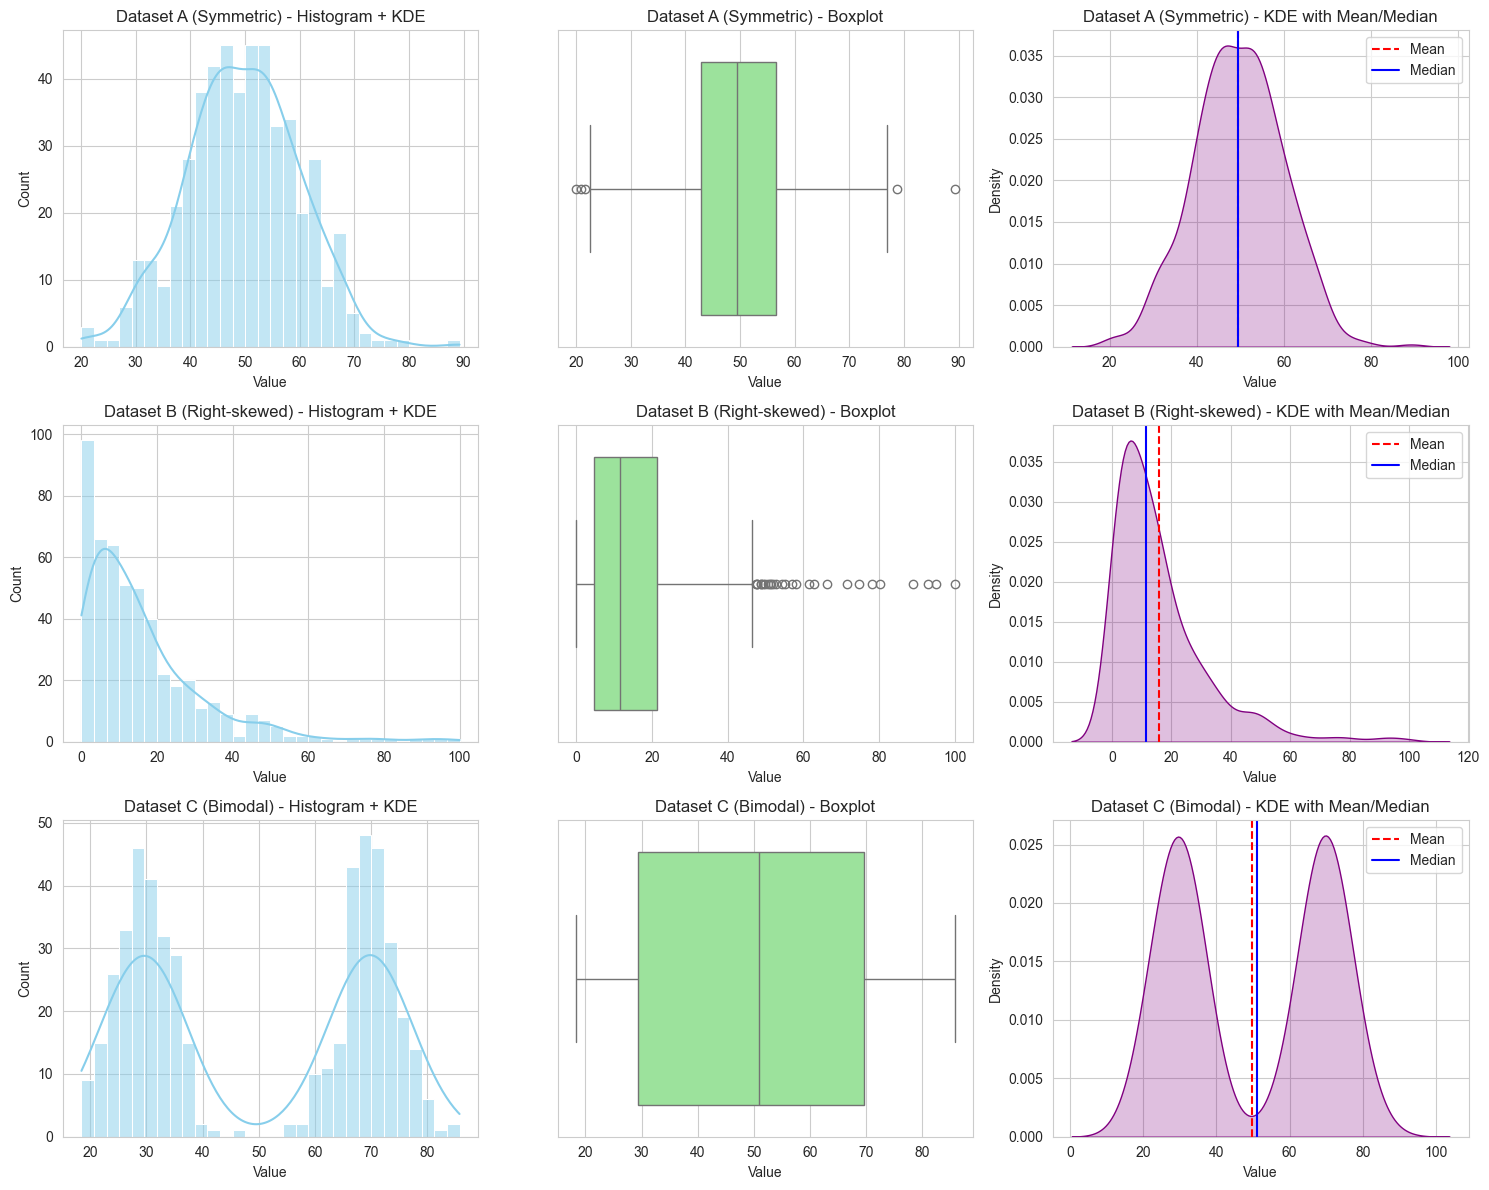

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, (name, data) in enumerate(datasets.items()):
    # Histogram + KDE
    sns.histplot(data, bins=30, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f"{name} - Histogram + KDE")
    axes[i, 0].set_xlabel("Value")
    axes[i, 0].set_ylabel("Count")

    # Boxplot
    sns.boxplot(x=data, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f"{name} - Boxplot")
    axes[i, 1].set_xlabel("Value")

    # KDE only
    sns.kdeplot(data, ax=axes[i, 2], color='purple', fill=True)
    mean = np.mean(data)
    median = np.median(data)
    axes[i, 2].axvline(mean, color="red", linestyle="--", label="Mean")
    axes[i, 2].axvline(median, color="blue", linestyle="-", label="Median")
    axes[i, 2].set_title(f"{name} - KDE with Mean/Median")
    axes[i, 2].set_xlabel("Value")
    axes[i, 2].legend()

plt.tight_layout()
plt.show()

**Guiding Question Answer:**  
- The **mean and median diverge most in Dataset B** due to the right skew and extreme values.  
- Visualization shows **why numbers alone can be misleading**—plots reveal the real shape of the data.

### Task 3: The Outlier Stress Test

In this task, we take **Dataset A (symmetric / normal)** and introduce extreme outliers to see how summary statistics change. 

We will:

1. Replace the 5 largest values with extreme outliers (multiply by 10).  
2. Compute summary statistics for the original and modified datasets.  
3. Create side-by-side boxplots with mean markers.  
4. Analyze which statistics are robust and which are sensitive to outliers.

In [16]:
# Copy Dataset A
dataset_A_modified = dataset_A.copy()

# Identify the indices of the 5 largest values
largest_indices = np.argsort(dataset_A_modified)[-5:]

# Multiply these 5 values by 10 to create extreme outliers
dataset_A_modified[largest_indices] = dataset_A_modified[largest_indices] * 10

In [18]:
df_outlier = pd.DataFrame({
    "Original_A": dataset_A,
    "Modified_A": dataset_A_modified
})

summary_outliers = pd.DataFrame({
    "Mean": df_outlier.mean(),
    "Median": df_outlier.median(),
    "Std Dev": df_outlier.std(),
    "Variance": df_outlier.var(),
    "IQR": df_outlier.quantile(0.75) - df_outlier.quantile(0.25),
    "Skewness": df_outlier.apply(stats.skew),
    "Kurtosis": df_outlier.apply(stats.kurtosis)
}).round(2)

summary_outliers

,Mean,Median,Std Dev,Variance,IQR,Skewness,Kurtosis
Original_A,49.56,49.41,10.21,104.30,13.73,0.02,0.14
Modified_A,56.61,49.41,74.02,5479.04,13.73,9.68,94.25


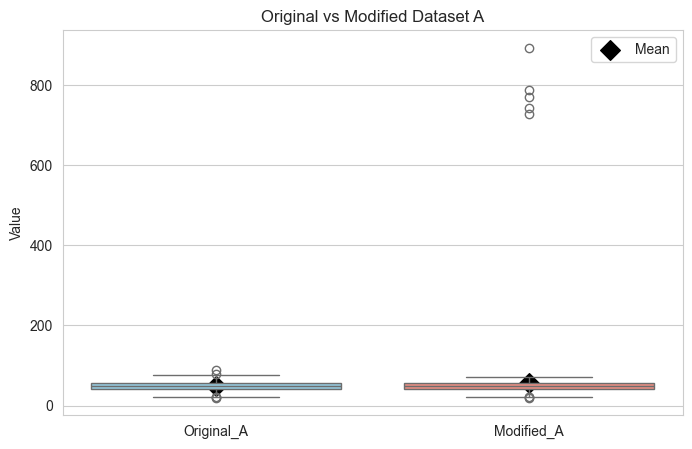

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_outlier, palette=["skyblue", "salmon"])

# Overlay mean as diamond marker
means = df_outlier.mean()
plt.scatter(range(len(means)), means, 
            marker="D", s=100, color="black", label="Mean")

plt.title("Original vs Modified Dataset A")
plt.ylabel("Value")
plt.legend()
plt.show()

### Interpretation

**Which statistics changed the most?**  
- **Mean, variance, standard deviation, skewness, kurtosis** all changed significantly after introducing outliers.  
- Extreme values pull the mean to higher numbers and inflate spread measures.

**Which statistics were robust?**  
- **Median and IQR** changed very little.  
- These are **resistant to extreme values** and better represent the “typical” data point in presence of outliers.

**If reporting a typical value:**  
- For the modified dataset with outliers, the **median** is a better choice than the mean because it is **not affected by extreme values**.